In [2]:
# --- Task 2: Signal Processing (spec-aligned) ---
import os, re, glob, math
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from scipy import signal
import pandas as pd

# ==== EDIT THESE PATHS IF NEEDED ====
ROOT_DIR      = r"C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing"
FOREHEAD_DIR  = os.path.join(ROOT_DIR, "Forehead")
SCLERA_DIR    = os.path.join(ROOT_DIR, "Sclera")

# Spec
FPS = 60.0
SPEC = {
    "forehead": {"W":128, "H":128, "C":3},
    "sclera"  : {"W":256, "H": 64, "C":3},
}

# HR search window (A3/A4/A10)
BPM_MIN, BPM_MAX = 40, 180
F_LO, F_HI = 0.7, 4.0   # Hz band-pass (A3/A4/A10)

plt.rcParams["figure.figsize"] = (7.5, 4.0)
plt.rcParams["axes.grid"] = True

print("ROOT_DIR:", ROOT_DIR)
print("Forehead dir:", FOREHEAD_DIR)
print("Sclera dir  :", SCLERA_DIR)
print("FPS:", FPS, "Band-pass:", (F_LO, F_HI), "BPM range:", (BPM_MIN, BPM_MAX))


ROOT_DIR: C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing
Forehead dir: C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Forehead
Sclera dir  : C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Sclera
FPS: 60.0 Band-pass: (0.7, 4.0) BPM range: (40, 180)


In [3]:
# --- Recursively find .bin files and classify as forehead or sclera by name/size ---

def dims_from_name(path):
    """Try to parse _W_H_ from filename; return (W,H) or None."""
    m = re.search(r"_(\d{2,4})_(\d{2,4})(?:_|\.bin$)", os.path.basename(path))
    if m:
        return int(m.group(1)), int(m.group(2))
    return None

def frames_if_match(path, W, H, C=3, bps=1):
    size = os.path.getsize(path)
    fbytes = W*H*C*bps
    return size // fbytes if size % fbytes == 0 else None

def list_bins_recursive(root):
    all_bins = sorted(glob.glob(os.path.join(root, "**", "*.bin"), recursive=True))
    forehead_bins, sclera_bins, unknown = [], [], []
    for p in all_bins:
        wh = dims_from_name(p)
        folder = os.path.basename(os.path.dirname(p)).lower()
        # prefer explicit dims in name
        if wh == (SPEC["forehead"]["W"], SPEC["forehead"]["H"]):
            T = frames_if_match(p, **SPEC["forehead"])
            if T: forehead_bins.append((p,T)); continue
        if wh == (SPEC["sclera"]["W"], SPEC["sclera"]["H"]):
            T = frames_if_match(p, **SPEC["sclera"])
            if T: sclera_bins.append((p,T)); continue
        # fallback: folder hint
        if "forehead" in folder:
            T = frames_if_match(p, **SPEC["forehead"])
            if T: forehead_bins.append((p,T)); continue
        if "sclera" in folder:
            T = frames_if_match(p, **SPEC["sclera"])
            if T: sclera_bins.append((p,T)); continue
        # final try: check both sizes
        Tf = frames_if_match(p, **SPEC["forehead"])
        Ts = frames_if_match(p, **SPEC["sclera"])
        if Tf and not Ts: forehead_bins.append((p,Tf)); continue
        if Ts and not Tf: sclera_bins.append((p,Ts)); continue
        unknown.append(p)
    return forehead_bins, sclera_bins, unknown

forehead_bins, sclera_bins, unknown = list_bins_recursive(ROOT_DIR)

def pretty(title, items, n=10):
    print(f"\n{title} ({len(items)})")
    for i,(p,T) in enumerate(items[:n],1):
        print(f"  [{i}] T={T:<6}  {p}")
    if len(items) > n:
        print(f"  ... and {len(items)-n} more")

pretty("Forehead bins (128x128x3)", forehead_bins)
pretty("Sclera bins (256x64x3)", sclera_bins)
if unknown:
    print("\n⚠️ Unknown (size/name mismatch):")
    for p in unknown: print("  -", p)

# keep only paths for the pipeline
forehead_bins = [p for p,_ in forehead_bins]
sclera_bins   = [p for p,_ in sclera_bins]



Forehead bins (128x128x3) (5)
  [1] T=13564   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Forehead\forehead_all_128_128_1.bin
  [2] T=13844   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Forehead\forehead_all_128_128_10.bin
  [3] T=15112   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Forehead\forehead_all_128_128_29.bin
  [4] T=15524   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Forehead\forehead_all_128_128_5.bin
  [5] T=13840   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Forehead\forehead_all_128_128_6.bin

Sclera bins (256x64x3) (5)
  [1] T=13564   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Sclera\sclera-eye_left_all_256_64_1.bin
  [2] T=13844   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Sclera\sclera-eye_left_all_256_64_10.bin
  [3] T=15112   C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\Sclera\sclera-eye_left_all_256

forehead_all_128_128_1.bin → shape=(T=13564,H=128,W=128,C=3), FPS=60.0


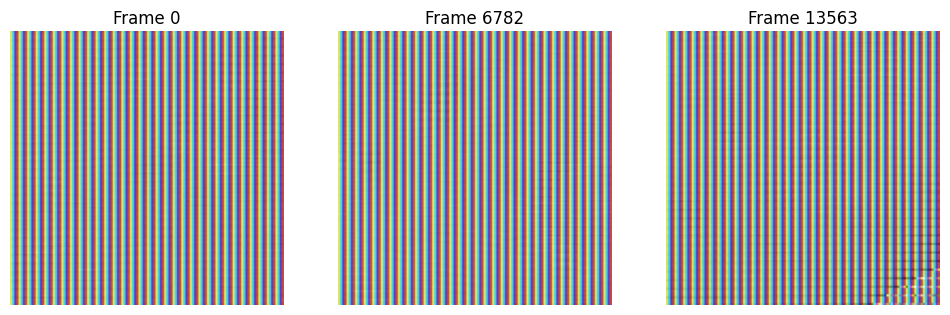

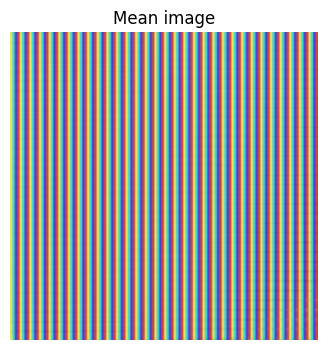

sclera-eye_left_all_256_64_1.bin → shape=(T=13564,H=64,W=256,C=3), FPS=60.0


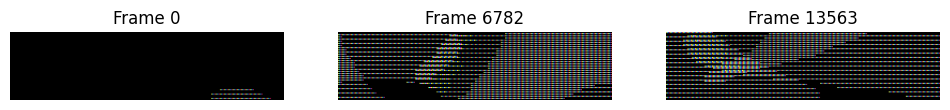

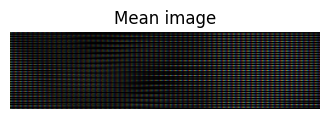

In [4]:
# --- Spec-aligned raw reader (row-major T×H×W×3) + preview ---

def read_bin_rgb(path, region):
    W, H, C = SPEC[region]["W"], SPEC[region]["H"], SPEC[region]["C"]
    raw = np.fromfile(path, dtype=np.uint8)
    frame_bytes = W*H*C
    if raw.size % frame_bytes != 0:
        raise ValueError(f"Size mismatch for {os.path.basename(path)} (bytes={raw.size}) "
                         f"not divisible by frame size {frame_bytes} (W={W},H={H},C={C}).")
    T = raw.size // frame_bytes
    arr = raw.reshape(T, H, W, C)
    return arr

def preview_bin(path, region, n_show=3):
    arr = read_bin_rgb(path, region)
    T,H,W,C = arr.shape
    print(f"{os.path.basename(path)} → shape=(T={T},H={H},W={W},C={C}), FPS={FPS}")
    idxs = [0, T//2, T-1] if T>=3 else list(range(T))
    idxs = idxs[:n_show]
    plt.figure(figsize=(4*len(idxs),4))
    for i,idx in enumerate(idxs,1):
        plt.subplot(1,len(idxs),i); plt.imshow(arr[idx]); plt.axis("off"); plt.title(f"Frame {idx}")
    plt.show()
    # mean image (helpful sanity check)
    mean_img = arr.mean(axis=0).astype(np.uint8)
    plt.figure(figsize=(4,4)); plt.imshow(mean_img); plt.axis("off"); plt.title("Mean image"); plt.show()
    return arr

# Try one forehead & one sclera for sanity
if forehead_bins:
    _FH = preview_bin(forehead_bins[0], region="forehead")
if sclera_bins:
    _SC = preview_bin(sclera_bins[0], region="sclera")


In [5]:
# --- Signal utilities (green channel, detrend, band-pass, Welch) ---

def mean_channel_timeseries(frames, channel="G"):
    ch = {"R":0,"G":1,"B":2}[channel.upper()]
    return frames[..., ch].mean(axis=(1,2)).astype(np.float32)

def zscore(x):
    mu, sd = np.mean(x), np.std(x) + 1e-8
    return (x - mu) / sd

def butter_bandpass(lo, hi, fs, order=3):
    nyq = 0.5*fs
    b,a = butter(order, [lo/nyq, hi/nyq], btype="band")
    return b,a

def bandpass_filter(sig, fs, lo=0.7, hi=4.0, order=3):
    b,a = butter_bandpass(lo, hi, fs, order)
    return filtfilt(b, a, sig)

def detrend_linear(x):
    return signal.detrend(x, type="linear")

def bpm_from_welch(sig, fs, bpm_min=40, bpm_max=180, nperseg=256, noverlap=128):
    f, Pxx = welch(sig, fs=fs, nperseg=min(nperseg, len(sig)), noverlap=min(noverlap, len(sig)//2))
    bpm_axis = f*60.0
    mask = (bpm_axis>=bpm_min) & (bpm_axis<=bpm_max)
    if not np.any(mask): return np.nan, np.nan, f, Pxx
    peak_idx = np.argmax(Pxx[mask])
    f_peak = f[mask][peak_idx]
    bpm = bpm_axis[mask][peak_idx]
    return float(bpm), float(f_peak), f, Pxx


In [6]:
# --- Process every .bin and compute BPM for forehead & sclera ---

def patient_id_from_path(p):
    base = os.path.splitext(os.path.basename(p))[0]
    # keep numbers/letters; strip trailing tokens like _forehead/_sclera if present
    base = re.sub(r"_(forehead|sclera|eye_(left|right))$", "", base, flags=re.IGNORECASE)
    return base

RESULTS = []

def process_file(path, region):
    frames = read_bin_rgb(path, region)
    ts = mean_channel_timeseries(frames, channel="G")  # A2/A4/A8/A10: green channel
    ts = detrend_linear(ts)                            # A1/A5/A12: detrend
    ts = bandpass_filter(ts, fs=FPS, lo=F_LO, hi=F_HI, order=3)  # A3/A4/A10
    ts = zscore(ts)
    bpm, fpk, freqs, psd = bpm_from_welch(ts, fs=FPS, bpm_min=BPM_MIN, bpm_max=BPM_MAX)
    return {
        "frames": frames, "sig": ts, "bpm": bpm, "f_peak": fpk, "freqs": freqs, "psd": psd
    }

# Build patient rows
ids = sorted(set([patient_id_from_path(p) for p in forehead_bins + sclera_bins]))
print("Patients detected:", len(ids))

for pid in ids:
    row = {"id": pid}
    # pick first file that starts with pid for each region
    fh_path = next((p for p in forehead_bins if patient_id_from_path(p)==pid), None)
    sc_path = next((p for p in sclera_bins   if patient_id_from_path(p)==pid), None)

    fh = process_file(fh_path, "forehead") if fh_path else None
    sc = process_file(sc_path, "sclera")   if sc_path else None

    row["_fh"] = fh; row["_sc"] = sc
    row["bpm_forehead"] = fh["bpm"] if fh else np.nan
    row["bpm_sclera"]   = sc["bpm"] if sc else np.nan
    row["n_frames_fh"]  = len(fh["sig"]) if fh else 0
    row["n_frames_sc"]  = len(sc["sig"]) if sc else 0
    RESULTS.append(row)

print("Processed", len(RESULTS), "patients.")


Patients detected: 10
Processed 10 patients.


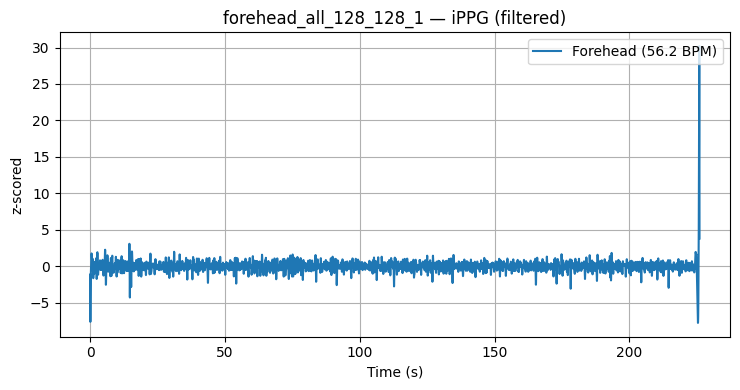

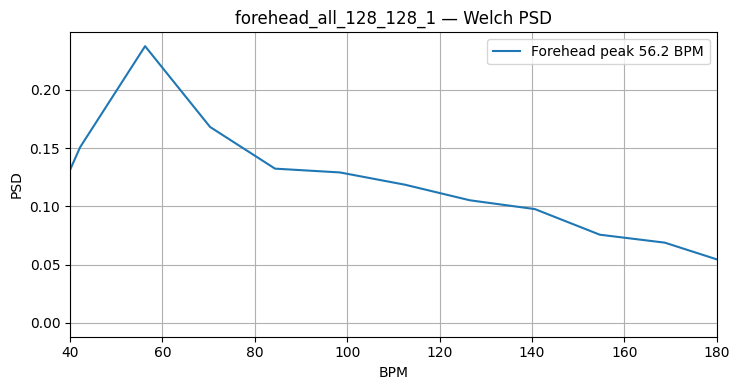

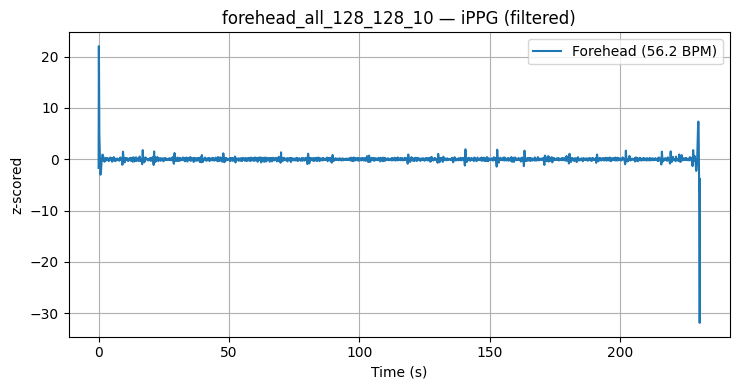

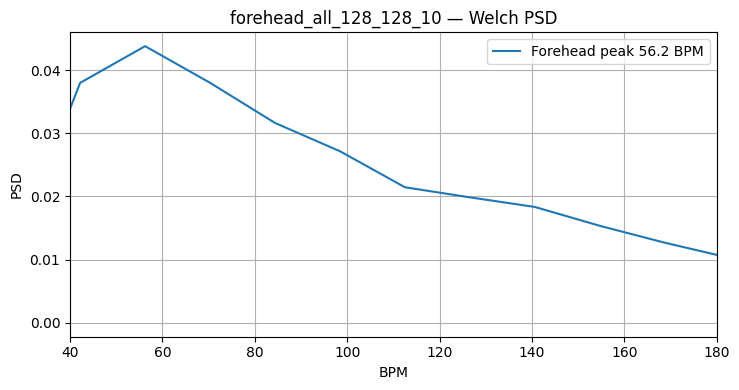

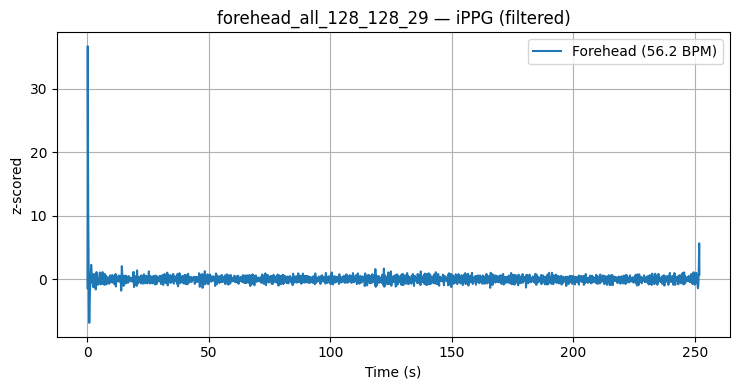

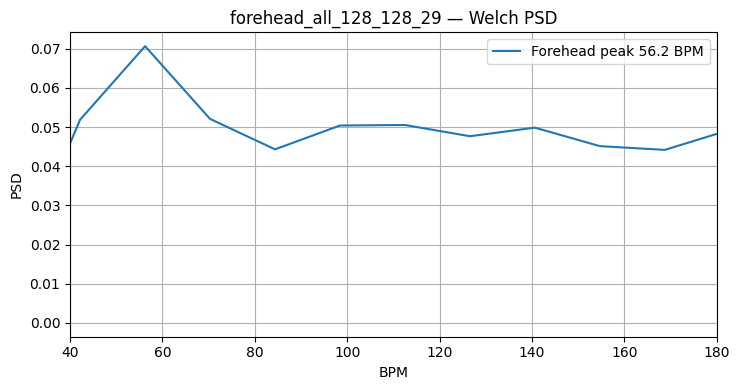

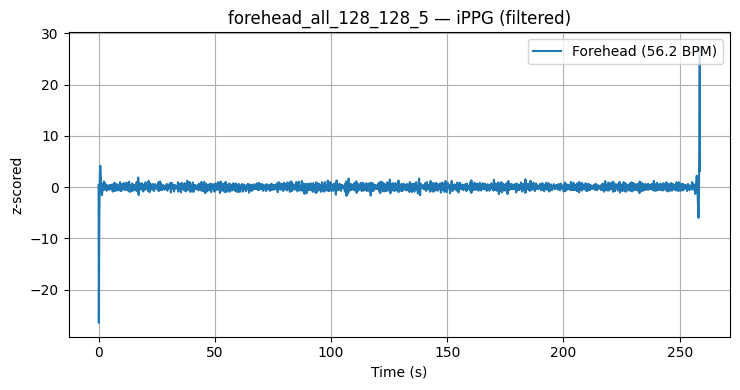

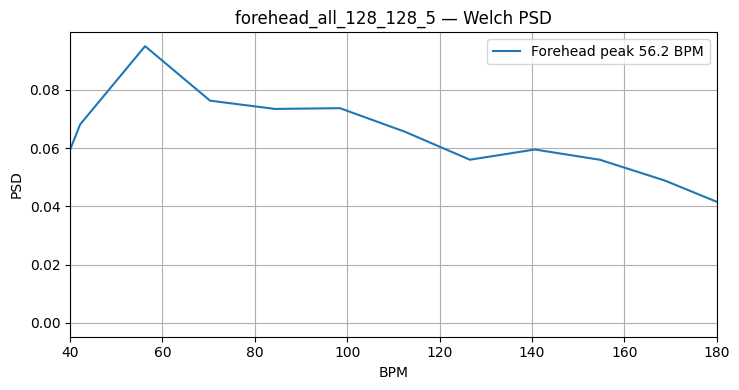

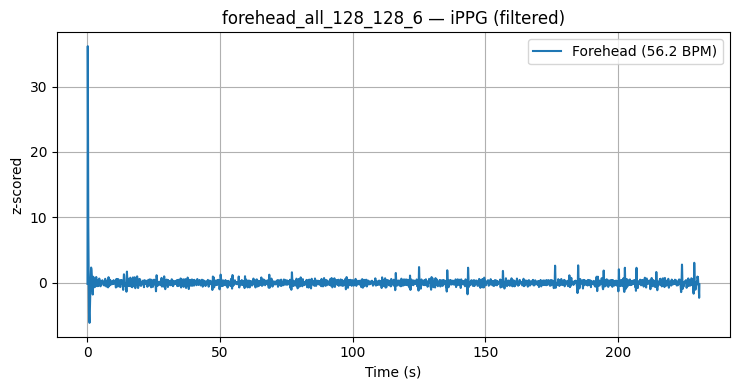

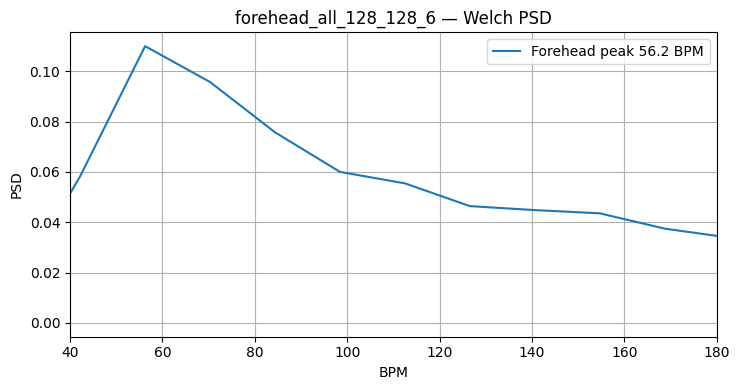

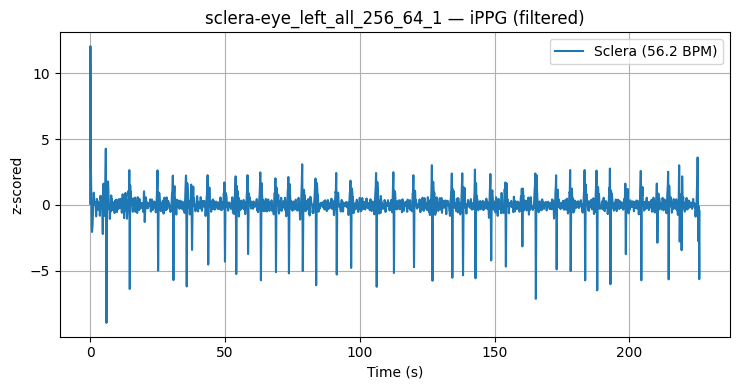

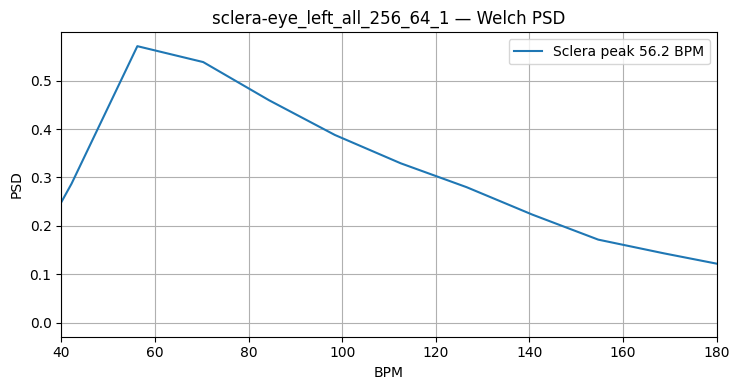

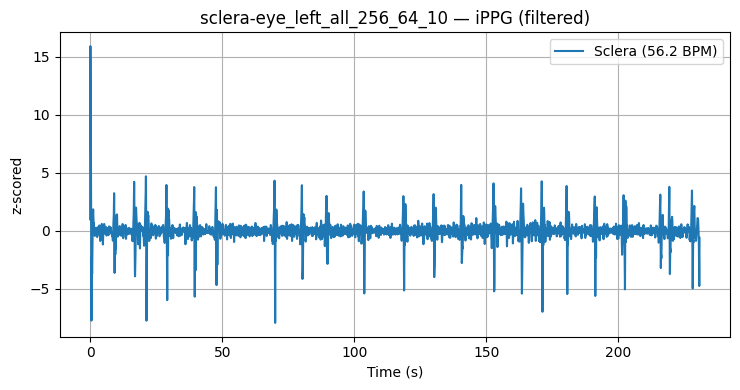

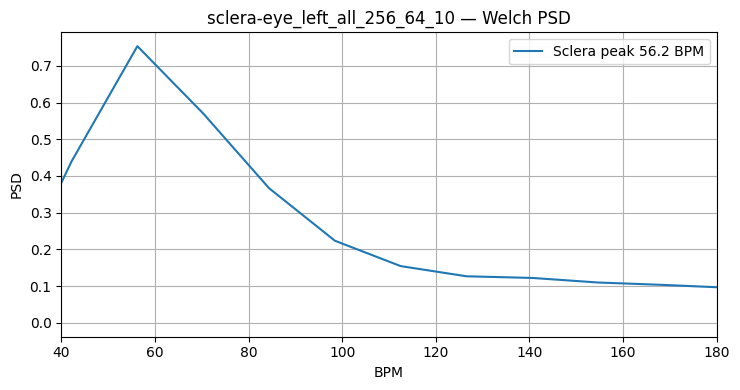

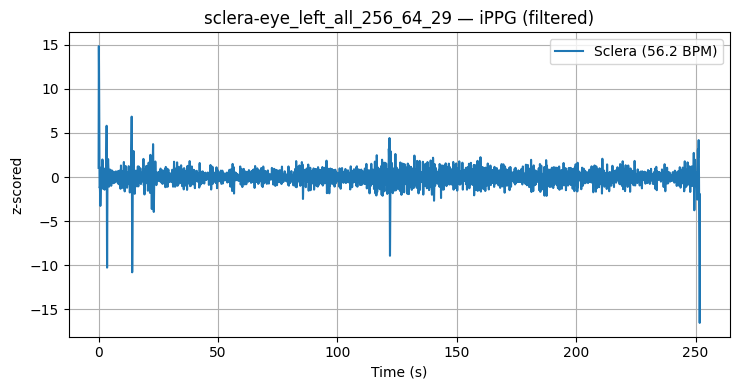

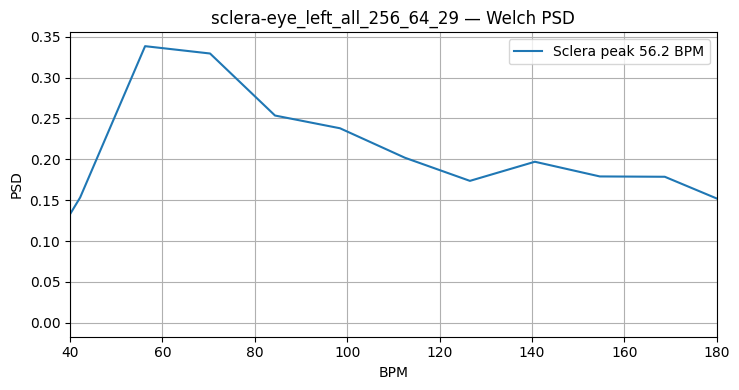

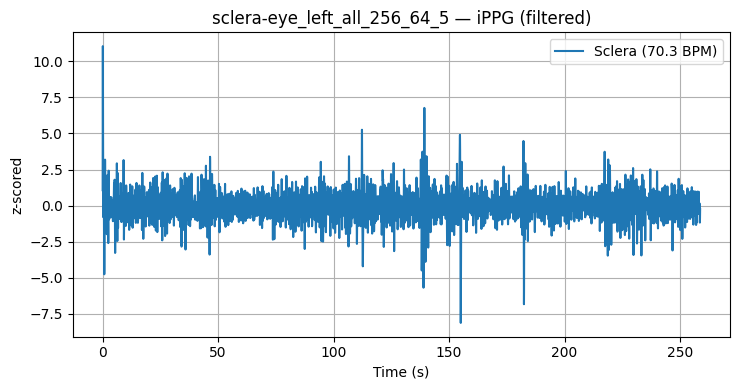

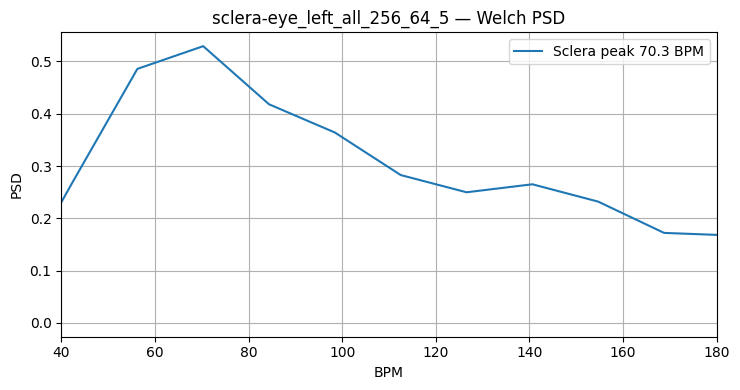

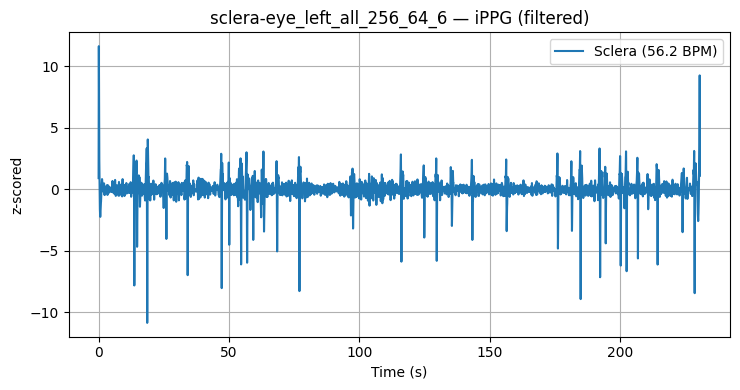

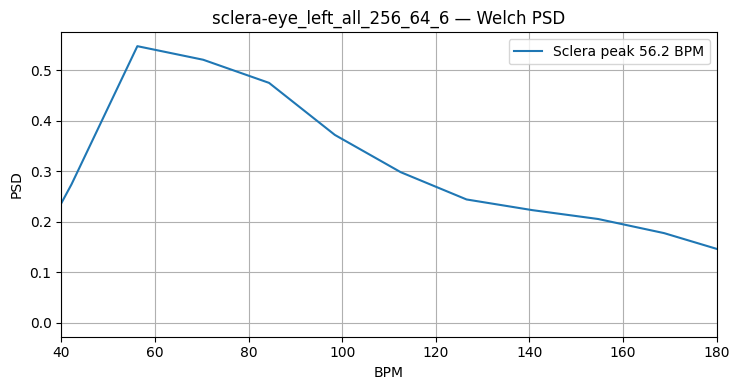

In [7]:
# --- Visualize per-patient: filtered signal and Welch PSD ---

def plot_patient(pid, fh, sc, save_dir="sp_qc"):
    os.makedirs(save_dir, exist_ok=True)

    # Time series
    plt.figure()
    if fh: plt.plot(np.arange(len(fh["sig"])) / FPS, fh["sig"], label=f"Forehead ({fh['bpm']:.1f} BPM)")
    if sc: plt.plot(np.arange(len(sc["sig"])) / FPS, sc["sig"], label=f"Sclera ({sc['bpm']:.1f} BPM)")
    plt.xlabel("Time (s)"); plt.ylabel("z-scored"); plt.title(f"{pid} — iPPG (filtered)")
    plt.legend(loc="upper right"); plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{pid}_timeseries.png"), dpi=150); plt.show()

    # PSD
    plt.figure()
    if fh:
        plt.plot(fh["freqs"]*60.0, fh["psd"], label=f"Forehead peak {fh['bpm']:.1f} BPM")
    if sc:
        plt.plot(sc["freqs"]*60.0, sc["psd"], label=f"Sclera peak {sc['bpm']:.1f} BPM")
    plt.xlim(BPM_MIN, BPM_MAX); plt.xlabel("BPM"); plt.ylabel("PSD")
    plt.title(f"{pid} — Welch PSD"); plt.legend(loc="upper right"); plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{pid}_psd.png"), dpi=150); plt.show()

for r in RESULTS:
    plot_patient(r["id"], r.get("_fh"), r.get("_sc"))


In [8]:
# --- Summary table ---
df = pd.DataFrame([{
    "id": r["id"],
    "bpm_forehead": r["bpm_forehead"],
    "bpm_sclera": r["bpm_sclera"],
    "n_frames_forehead": r["n_frames_fh"],
    "n_frames_sclera": r["n_frames_sc"],
    "fps": FPS
} for r in RESULTS]).sort_values("id")

display(df)
out_csv = os.path.join(ROOT_DIR, "sp_results_summary.csv")
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)


,id,bpm_forehead,bpm_sclera,n_frames_forehead,n_frames_sclera,fps
0,forehead_all_128_128_1,56.25,NaN,13564,0,60.0
1,forehead_all_128_128_10,56.25,NaN,13844,0,60.0
2,forehead_all_128_128_29,56.25,NaN,15112,0,60.0
3,forehead_all_128_128_5,56.25,NaN,15524,0,60.0
4,forehead_all_128_128_6,56.25,NaN,13840,0,60.0
5,sclera-eye_left_all_256_64_1,NaN,56.2500,0,13564,60.0
6,sclera-eye_left_all_256_64_10,NaN,56.2500,0,13844,60.0
7,sclera-eye_left_all_256_64_29,NaN,56.2500,0,15112,60.0
8,sclera-eye_left_all_256_64_5,NaN,70.3125,0,15524,60.0
9,sclera-eye_left_all_256_64_6,NaN,56.2500,0,13840,60.0


Saved: C:/Users/kemal/OneDrive/Masaüstü/Jupyter/Task2-Signal-Processing\sp_results_summary.csv
